In [1]:
import sys
sys.path.insert(0,'..')
import os 
import pickle 
import dill

import oqupy
import oqupy.operators as op
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.transforms import ScaledTranslation

#plt.style.use('physrev') 
#plt.rcParams['figure.dpi'] = "75"

import numpy as np
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from scipy.optimize import minimize,Bounds

# ----------------- Parameters --------------

# --- Bath ----

omega_cutoff = 5.0*2*np.pi
wq0 = 5.0*2*np.pi

alpha = 0.03
temperature = 0.0 
t_max = 11.0
dt = 1./omega_cutoff/np.sqrt(3)/2
num_steps = int(t_max/dt)
t_list = np.linspace(0,t_max,num_steps)
dt_half = dt/2 # Accounts for the fact that we use half-time propagators.
num_steps_half = int(t_max/dt_half)
t_list_half = np.linspace(0,t_max,num_steps_half)

N=6000
c = 3*omega_cutoff/N

name = 'alpha{}tmax{}wc{}wq0{}exponential'.format(alpha,round(t_max,3),round(omega_cutoff/2/np.pi,2),round(wq0/2/np.pi,2))
name_replaced = name.replace('.','-')
#name_path = os.path.dirname(__file__)+'/opt/'+name_replaced  
name_path = os.getcwd()+'/opt/'+name_replaced  


opt_file = open(name_path, 'rb')    
dict_run = pickle.load(opt_file)
opt_file.close()

x0 = dict_run['optimization_result'].x


# Oqupy calculation

from oqupy.iTEBD_TEMPO_useoqupybath import iTEBD_TEMPO_oqupy
from oqupy.process_tensor import TTInvariantProcessTensor
from oqupy.tti_tempo import TTITempo

name = 'alpha{}wc{}wq0{}exponential'.format(alpha,round(omega_cutoff/2/np.pi,2),round(wq0/2/np.pi,2))
name_replaced = name.replace('.','-')
#name_path = os.path.dirname(__file__)+'/pt/'+name_replaced+".processTensor"       
name_path = os.getcwd() + '/pt/'+name_replaced+".processTensor"
pt_file = open(name_path,'rb')
process_tensor_tebd = dill.load(pt_file)
pt_file.close()


h_x_opt = np.expand_dims(dict_run['optimization_result'].x,1)



In [2]:
# Run the optimized dynamics
def discrete_hamiltonian(hx):
        return hx*op.sigma('x')
system = oqupy.ParameterizedSystem(discrete_hamiltonian)

initial_state = op.spin_dm('mixed')
target_state = op.spin_dm('x-')
target_derivative = target_state.T

grad_res_opt = oqupy.state_gradient(
    system=system,
    initial_state=initial_state,
    target_derivative=target_derivative,
    process_tensors=[process_tensor_tebd],
    num_steps=num_steps,
    parameters=h_x_opt,
    only_dynamics=True)

dynamics_opt = grad_res_opt['dynamics']
t, s_x_opt = dynamics_opt.expectations(op.sigma('x'), real=True)

--> Compute forward propagation:
100.0% 1197 of 1197 [########################################] 00:00:04
Elapsed time: 4.6s


In [120]:
pt=process_tensor_tebd
hx=h_x_opt[0]
system=oqupy.System(hx*op.sigma('x'))
pt.set_length(1000)
spin_down = oqupy.operators.spin_dm("down")
s_z = 0.5*oqupy.operators.sigma("z")
s_x = 0.5*oqupy.operators.sigma("x")
corr = oqupy.PowerLawSD(alpha, 1, omega_cutoff, temperature = 0.0)
bath = oqupy.Bath(s_z, corr)
w = omega_cutoff
delta = 0.1 * omega_cutoff

initial_state = op.spin_dm('mixed')


In [4]:
if os.path.isfile('bath_corr.pkl'):
    print('loading correlation from file')
    with open('bath_corr.pkl', 'rb') as f:
        bath_corr=dill.load(f)
else:
    print('generating correlations and saving to file')
    bath_corr = oqupy.bath_dynamics.TwoTimeBathCorrelations(system, bath, pt, initial_state)
    tlist, occ = bath_corr.occupation(w, delta, change_only = True)
    with open('bath_corr.pkl', 'wb') as f:
        dill.dump(bath_corr,f) 
    energy = w * occ


#plt.plot(tlist[1:],energy)
#plt.show()

loading correlation from file


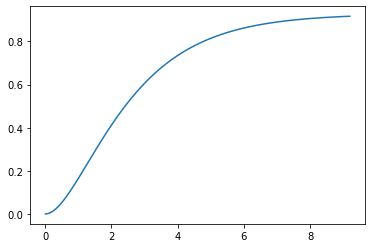

In [5]:
tlist, occ = bath_corr.occupation(w, delta, change_only = True)
plt.plot(tlist[1:],occ)

In [ ]:
# let's generate a density plot
allocs=[]
ws=np.linspace(1,omega_cutoff*2,50)
for w in ws:
    tlist, occ = bath_corr.occupation(w, delta, change_only = True)
    allocs.append(list(occ))


In [ ]:
xs,ys=np.meshgrid(tlist[1:],ws)
zs=allocs
plt.pcolormesh(xs,ys,zs)
plt.show()

In [ ]:
from matplotlib import cm
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.plot_surface(xs, ys, np.array(zs), cmap=cm.Blues)


/var/folders/wt/793m2p3j0_s22f9qtt6sch940000gn/T/ipykernel_76605/1006985067.py:10: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


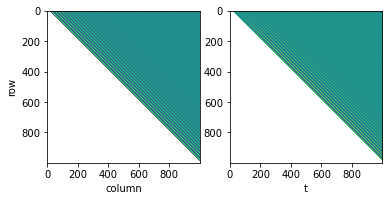

In [6]:

fig, (ax1,ax2) = plt.subplots(1,2)
ax1.imshow(np.array(bath_corr._system_correlations).real)
ax1.set_ylabel('row')
ax1.set_xlabel('column')
#fig.colorbar()
ax2.imshow(np.array(bath_corr._system_correlations).imag)
ax2.set_xlabel('t')
#ax2.set_ylabel('tprime')
#ax2.colorbar()
fig.show()

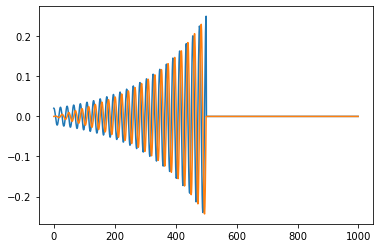

In [8]:
cfarr=np.array(bath_corr._system_correlations)
cfarr[np.isnan(cfarr)] = 0
cfarr[10,:]
plt.clf()
plt.plot(cfarr[:,500].real)
plt.plot(cfarr[:,500].imag)
plt.show()

In [110]:
# do the fft along the t' axis
pad=100
n=cfarr.shape[0]+pad
freq=np.fft.fftfreq(n,dt)
ftcfarr=dt*np.fft.ifft(cfarr,n=n,axis=0,norm="forward")

# we only need the positive frequency part

omega=freq[0:n//2]*2*np.pi
disps=ftcfarr[0:n//2,:]

# multiply the columns (each of which is a particular time)
# by the spectral density

disps=disps*corr.spectral_density(omega)[:,np.newaxis]

# construct the matrix exp(-i omega t)
# since we have a_nm, first index is frequency, second is time

xs,ys=np.meshgrid(dt*np.arange(disps.shape[1]),omega)

# multiply this in

disps=-1.0j*np.exp(-1.0j*xs*ys)*disps





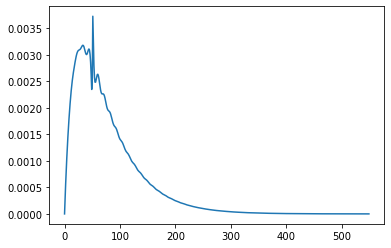

In [117]:
plt.clf()
plt.plot(np.abs(disps[:,999]))

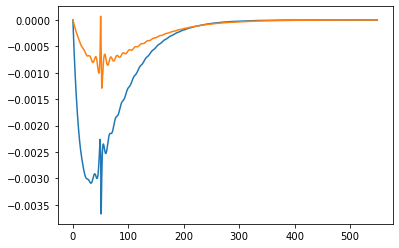

In [118]:

plt.clf()
plt.plot(disps[:,999].real)
plt.plot(disps[:,999].imag)

(-17.063575080068002, 150.0)

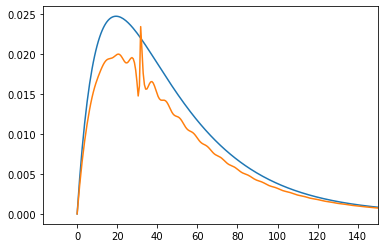

In [139]:
# compare with displacements in the polaron state
wq=2*hx
plt.clf()
plt.plot(omega,2*corr.spectral_density(omega)/(wq+omega))
plt.plot(omega,2*np.pi*np.abs(disps[:,999]))
plt.xlim(right=150)
# roughly agrees after i stuck a 2 and a 2pi in the above by guessing

NameError: name 'wq' is not defined